In [3]:
import pandas as pd
import oracledb
from sqlalchemy import create_engine
from pathlib import Path
data_path = Path.cwd()/ 'data' / "titanic.csv"
df = pd.read_csv(data_path)
# df.head()
# df.tail()
df.info()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
pd.set_option("display.max_rows", 10)


In [5]:
df = df.astype({"PassengerId": "int", 
                "Survived": "bool",
                "Pclass": "category",
                "Sex": "category"})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    bool    
 2   Pclass       891 non-null    category
 3   Name         891 non-null    object  
 4   Sex          891 non-null    category
 5   Age          714 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Cabin        204 non-null    object  
 11  Embarked     889 non-null    object  
dtypes: bool(1), category(2), float64(2), int64(3), object(4)
memory usage: 65.6+ KB


In [6]:
pd.set_option("display.max_rows", 20)
df.isna().sum()
df_1 = df.isna()
df_1.mean()

PassengerId    0.000000
Survived       0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
Age            0.198653
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.000000
Cabin          0.771044
Embarked       0.002245
dtype: float64

In [7]:
# df["Age"].astype("Int64")

In [8]:
import seaborn as sns

# sns.heatmap(df.isna(), cbar=False)

df.describe()


,PassengerId,Age,SibSp,Parch,Fare
count,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,29.699118,0.523008,0.381594,32.204208
std,257.353842,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,38.000000,1.000000,0.000000,31.000000
max,891.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
df.iloc[0:5] 
corr_df = df[["PassengerId", "Age", "SibSp", "Parch","Fare"]].corr()
df.loc[:, ["PassengerId", "Age", "SibSp", "Parch","Fare"]].corr()
tmp = df.select_dtypes(include="number").corr()
type(tmp)
tmp.style.background_gradient(cmap="RdYlGn", vmin=-1, vmax=1)

# tmp = df.corr(numeric_only=True)
# type(tmp)
# tmp.style.background_gradient(cmap="RdYlGn", vmin=-1, vmax=1)
# sns.heatmap(corr_df, annot=True, cmap="coolwarm", vmin=-1, vmax=1)

,PassengerId,Age,SibSp,Parch,Fare
PassengerId,1.000000,0.036847,-0.057527,-0.001652,0.012658
Age,0.036847,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.096067,0.159651,0.216225,1.000000


In [10]:
import pandas as pd
# concat, merge (left_on,right_on,how),join(index)
df1 = pd.DataFrame({
    "A": [1, 2,4]
})

df2 = pd.DataFrame({
    "A": [3, 4,5]
})

pd.concat([df1, df2], axis=1, ignore_index=True)

,0,1
0,1,3
1,2,4
2,4,5


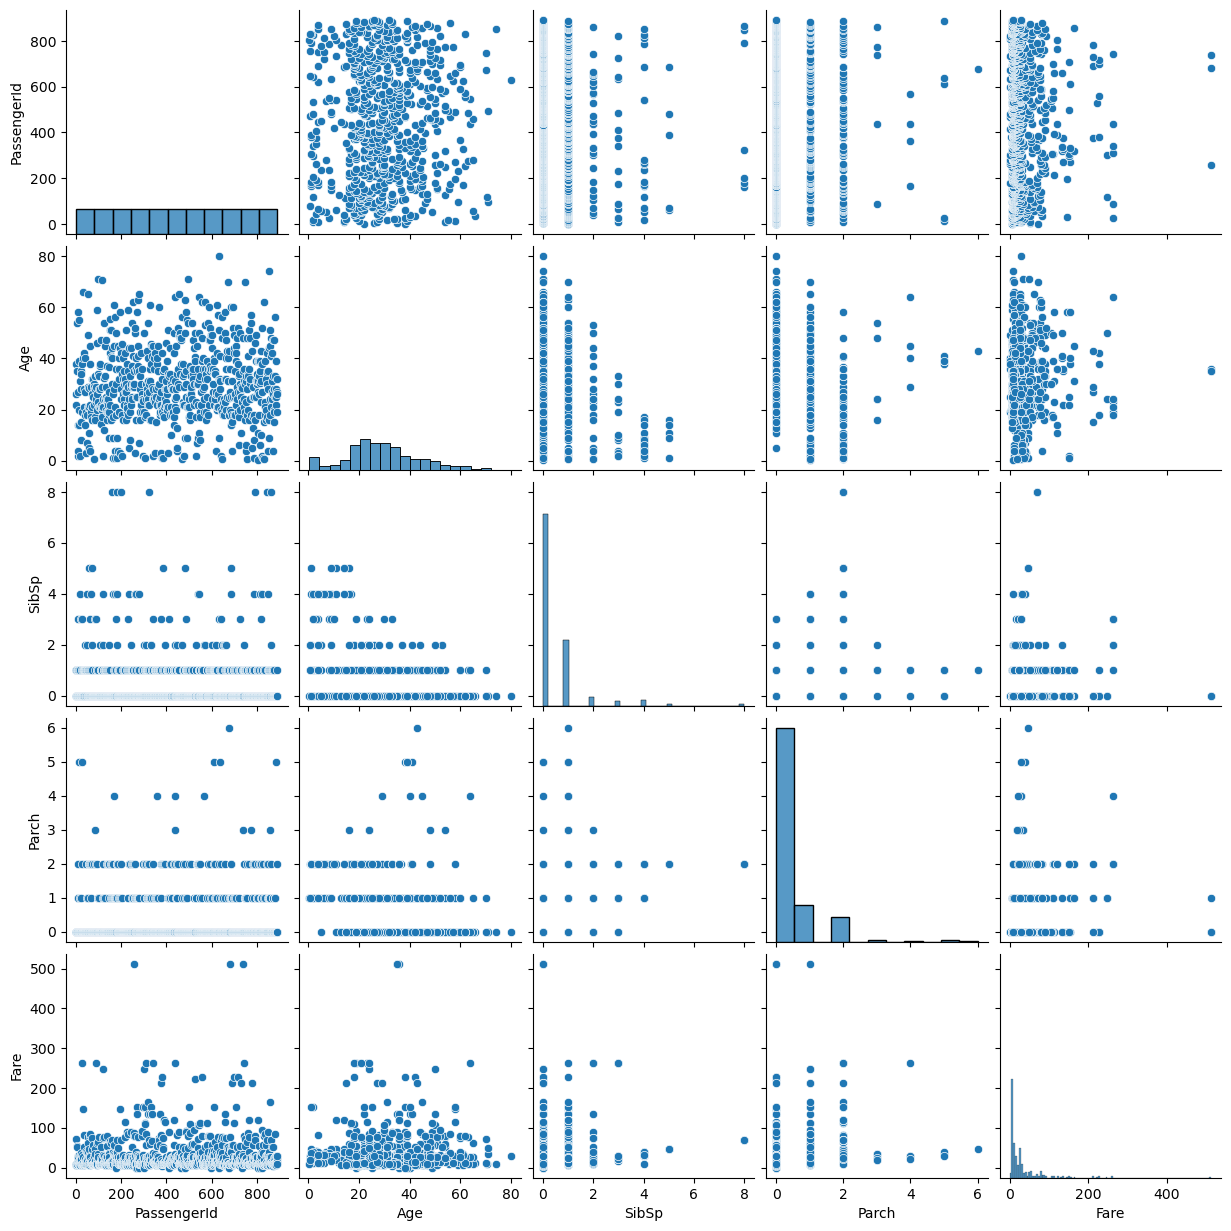

In [11]:
sns.pairplot(df.select_dtypes(include="number") )

In [12]:
from sqlalchemy import text
oracle_user_name = "system"
db_oracle_password = "Oracle1234"
oracle_host = "localhost"
oracle_port = 1521
oracle_service_name = "xepdb1"



engine = create_engine(
    f"oracle+oracledb://{oracle_user_name}:{db_oracle_password}@{oracle_host}:{oracle_port}/?service_name={oracle_service_name}"
)

# with engine.connect() as conn:
#     conn.execute(text('''
#         CREATE USER GQY 
#         IDENTIFIED BY Oracle1234
#         DEFAULT TABLESPACE users
#         TEMPORARY TABLESPACE temp
#         QUOTA UNLIMITED ON users
#     '''))
#     conn.execute(text('''
#         GRANT CONNECT, RESOURCE TO GQY
#     '''))   
#     conn.commit()


In [13]:
# oracle_user_name = "GQY"
# db_oracle_password = "Oracle1234"
# oracle_host = "localhost"
# oracle_port = 1521
# oracle_service_name = "xepdb1"

# engine_gqy = create_engine(
#     f"oracle+oracledb://{oracle_user_name}:{db_oracle_password}@{oracle_host}:{oracle_port}/?service_name={oracle_service_name}"
# )
# with engine_gqy.connect() as conn:
#     try:
#         conn.execute(text("DROP TABLE test"))
#         conn.commit()
#     except Exception as e:
#         print(e)
#     conn.execute(text("""
#                                CREATE TABLE test (
#                                    id NUMBER PRIMARY KEY,
#                                    name VARCHAR2(50)
#                                )
#                                """))
#     conn.execute(text("""
#                                INSERT INTO test (id, name) VALUES (1, 'Alice')
                            
#                                """))
#     conn.commit()  
#     result = conn.execute(text("SELECT * FROM test"))
#     for row in result:
#         print(row)

In [14]:
import sqlite3

data_murder = Path.cwd()/"data"/"sql-murder-mystery.db"
conn = sqlite3.connect(data_murder)
cursor = conn.cursor()
cursor = cursor.execute("select name from sqlite_master where type='table'")
print(cursor.fetchall())
rst = pd.read_sql("select name from sqlite_master where type='table'", conn)
rst.head(10)


[('crime_scene_report',), ('drivers_license',), ('facebook_event_checkin',), ('interview',), ('get_fit_now_member',), ('get_fit_now_check_in',), ('solution',), ('income',), ('person',)]


,name
0,crime_scene_report
1,drivers_license
2,facebook_event_checkin
3,interview
4,get_fit_now_member
5,get_fit_now_check_in
6,solution
7,income
8,person


In [15]:
df_crime_scene_report = pd.read_sql("select * from crime_scene_report", conn)
(df_crime_scene_report.head(5))
# df_crime_scene_report.info()





,date,type,description,city
0,20180115,robbery,A Man Dressed as Spider-Man Is on a Robbery Spree,NYC
1,20180115,murder,Life? Dont talk to me about life.,Albany
2,20180115,murder,"Mama, I killed a man, put a gun against his he...",Reno
3,20180215,murder,REDACTED REDACTED REDACTED,SQL City
4,20180215,murder,Someone killed the guard! He took an arrow to ...,SQL City


In [16]:
df_drivers_license = pd.read_sql("select * from drivers_license", conn  )
df_drivers_license.head(5)

,id,age,height,eye_color,hair_color,gender,plate_number,car_make,car_model
0,100280,72,57,brown,red,male,P24L4U,Acura,MDX
1,100460,63,72,brown,brown,female,XF02T6,Cadillac,SRX
2,101029,62,74,green,green,female,VKY5KR,Scion,xB
3,101198,43,54,amber,brown,female,Y5NZ08,Nissan,Rogue
4,101255,18,79,blue,grey,female,5162Z1,Lexus,GS


In [17]:
df_facebook_event_checking = pd.read_sql("select * from facebook_event_checkin", conn)
df_facebook_event_checking.head(5)

,person_id,event_id,event_name,date
0,28508,5880,Nudists are people who wear one-button suits.\n,20170913
1,63713,3865,but that's because it's the best book on anyth...,20171009
2,63713,3999,"If Murphy's Law can go wrong, it will.\n",20170502
3,63713,6436,Old programmers never die. They just branch t...,20170926
4,82998,4470,Help a swallow land at Capistrano.\n,20171022


In [18]:
df_interview = pd.read_sql("select * from interview", conn)
df_interview.head(5)

,person_id,transcript
0,28508,‘I deny it!’ said the March Hare.\n
1,63713,\n
2,86208,"way, and the whole party swam to the shore.\n"
3,35267,"lessons in here? Why, there’s hardly room for ..."
4,33856,\n


In [19]:
df_get_fit_now_member = pd.read_sql("select * from get_fit_now_member", conn)
df_get_fit_now_member.head(5)

,id,person_id,name,membership_start_date,membership_status
0,NL318,65076,Everette Koepke,20170926,gold
1,AOE21,39426,Noe Locascio,20171005,regular
2,2PN28,63823,Jeromy Heitschmidt,20180215,silver
3,0YJ24,80651,Waneta Wellard,20171206,gold
4,3A08L,32858,Mei Bianchin,20170401,silver


In [20]:
df_get_fit_now_check_in = pd.read_sql("select * from get_fit_now_check_in", conn)
df_get_fit_now_check_in.head(5)

,membership_id,check_in_date,check_in_time,check_out_time
0,NL318,20180212,329,365
1,NL318,20170811,469,920
2,NL318,20180429,506,554
3,NL318,20180128,124,759
4,NL318,20171027,418,1019


In [21]:
df_person = pd.read_sql("select * from person", conn)
df_person.head(5)

,id,name,license_id,address_number,address_street_name,ssn
0,10000,Christoper Peteuil,993845,624,Bankhall Ave,747714076
1,10007,Kourtney Calderwood,861794,2791,Gustavus Blvd,477972044
2,10010,Muoi Cary,385336,741,Northwestern Dr,828638512
3,10016,Era Moselle,431897,1987,Wood Glade St,614621061
4,10025,Trena Hornby,550890,276,Daws Hill Way,223877684


In [22]:
df_income = pd.read_sql("select * from income", conn)
df_income.head(5)

,ssn,annual_income
0,100009868,52200
1,100169584,64500
2,100300433,74400
3,100355733,35900
4,100366269,73000


In [34]:
#step 1
df_crime_scene_report.info()
df_crime_scene_report.head(5    )
df_crime_scene_report = df_crime_scene_report.astype({"city": "category", "type": "category","description": "string"    })
#step 1
df_crime_scene_report.info()

df_crime_scene_report[(df_crime_scene_report.city == "SQL City") & (df_crime_scene_report.date == 20180115) & (df_crime_scene_report.type == "murder") ].description.iloc[0]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1228 entries, 0 to 1227
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   date         1228 non-null   int64   
 1   type         1228 non-null   category
 2   description  1228 non-null   string  
 3   city         1228 non-null   category
dtypes: category(2), int64(1), string(1)
memory usage: 34.3 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1228 entries, 0 to 1227
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   date         1228 non-null   int64   
 1   type         1228 non-null   category
 2   description  1228 non-null   string  
 3   city         1228 non-null   category
dtypes: category(2), int64(1), string(1)
memory usage: 34.3 KB


'Security footage shows that there were 2 witnesses. The first witness lives at the last house on "Northwestern Dr". The second witness, named Annabel, lives somewhere on "Franklin Ave".'

In [59]:
#step 2
df_person.head(5)
suspect_id_1 = df_person[(df_person.address_street_name == "Franklin Ave") &(df_person.name.str.contains("Annabel"))].id.iloc[0]
suspect_id_2 = df_person[(df_person.address_street_name == "Northwestern Dr")].id.loc[df_person.address_number.idxmax()]
print(suspect_id_1,suspect_id_2)
df_person.info()

16371 14887
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10011 entries, 0 to 10010
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   10011 non-null  int64 
 1   name                 10011 non-null  object
 2   license_id           10011 non-null  int64 
 3   address_number       10011 non-null  int64 
 4   address_street_name  10011 non-null  object
 5   ssn                  10011 non-null  object
dtypes: int64(3), object(3)
memory usage: 469.4+ KB


In [55]:
#step 3
df_interview.head(5)
interviews = df_interview[(df_interview.person_id == suspect_id_1) | (df_interview.person_id == suspect_id_2)]
df_interview.head(5)
print(interviews.transcript.iloc[0])
print(interviews.transcript.iloc[1])

I heard a gunshot and then saw a man run out. He had a "Get Fit Now Gym" bag. The membership number on the bag started with "48Z". Only gold members have those bags. The man got into a car with a plate that included "H42W".
I saw the murder happen, and I recognized the killer from my gym when I was working out last week on January the 9th.


In [83]:
df_get_fit_now_member.head(5)
df_drivers_license.head(5)
df_get_fit_now_member =df_get_fit_now_member.astype({"id": "string", "name": "string","name":"string","membership_status": "category"      })
df_member_person = pd.merge(df_get_fit_now_member, df_person, left_on="person_id", right_on="id", how="inner",suffixes=("_member", "_person"))
df_member_person_with_license = pd.merge(df_member_person, df_drivers_license, left_on="license_id", right_on="id", how="inner", suffixes=("_member_person", "_drivers_license"))
df_member_person_with_license.head(5)
df_member_person_with_license.info()


df_member_person_with_license[(df_member_person_with_license.id_member.str.startswith("48Z")) & (df_member_person_with_license.membership_status == "gold")]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183 entries, 0 to 182
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   id_member              183 non-null    string  
 1   person_id              183 non-null    int64   
 2   name_member            183 non-null    string  
 3   membership_start_date  183 non-null    int64   
 4   membership_status      183 non-null    category
 5   id_person              183 non-null    int64   
 6   name_person            183 non-null    object  
 7   license_id             183 non-null    int64   
 8   address_number         183 non-null    int64   
 9   address_street_name    183 non-null    object  
 10  ssn                    183 non-null    object  
 11  id                     183 non-null    int64   
 12  age                    183 non-null    int64   
 13  height                 183 non-null    int64   
 14  eye_color              183 non-null    obj

,id_member,person_id,name_member,membership_start_date,membership_status,id_person,name_person,license_id,address_number,address_street_name,ssn,id,age,height,eye_color,hair_color,gender,plate_number,car_make,car_model
181,48Z55,67318,Jeremy Bowers,20160101,gold,67318,Jeremy Bowers,423327,530,"Washington Pl, Apt 3A",871539279,423327,30,70,brown,brown,male,0H42W2,Chevrolet,Spark LS
